# Notebook 1: Dataset Download & Exploration

**Goal:** Download HotpotQA, understand its structure, fetch Wikipedia pages, and build a small corpus saved to `data/` for use in notebooks 2,3,4.

**Thing to do:**
- Explore HotpotQA (multi-hop questions needing 2 Wikipedia pages)
- Fetch Wikipedia pages via the Wikipedia API
- Explore RAG corpus dictionary

**Run order:** This is notebook **1 of 4**. Run this first — it creates `data/corpus.json` and `data/questions.json`.


In [1]:
# Install required packages (run once, safe to re-run)
%pip install datasets sentence-transformers faiss-cpu networkx beautifulsoup4 requests matplotlib tqdm -q
print('All packages ready.')


Note: you may need to restart the kernel to use updated packages.
All packages ready.


In [4]:
import json
import time
import html as html_lib
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from collections import Counter

import requests
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from datasets import load_dataset, load_from_disk


# ── Paths ────────────────────────────────────────────────────────────────────
if Path('utils.py').exists():
    BASE_DIR = Path('.')          
else:
    BASE_DIR = Path('notebooks')

DATA_DIR = BASE_DIR / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)
CORPUS_PATH  = DATA_DIR / 'corpus.json'
QUESTIONS_PATH = DATA_DIR / 'questions.json'

print(f'Base dir : {BASE_DIR.resolve()}')
print(f'Data dir : {DATA_DIR.resolve()}')


Base dir : C:\Users\Admin\OneDrive\Desktop\AI-research assignment\HyperRag\notebooks
Data dir : C:\Users\Admin\OneDrive\Desktop\AI-research assignment\HyperRag\notebooks\data


---
## Step 1 — Load HotpotQA

HotpotQA is a **multi-hop** question answering dataset. Every question requires combining information from exactly **two Wikipedia pages**.


In [5]:
HOTPOTQA_SNAPSHOT = DATA_DIR / "hotpotqa_fullwiki_train"

print("Loading HotpotQA fullwiki train split ...")

if HOTPOTQA_SNAPSHOT.exists():
    dataset = load_from_disk(str(HOTPOTQA_SNAPSHOT))
    print(f"Loaded from disk: {HOTPOTQA_SNAPSHOT.resolve()}")
else:
    dataset = load_dataset("hotpot_qa", "fullwiki", split="train")
    dataset.save_to_disk(str(HOTPOTQA_SNAPSHOT))
    print(f"Saved to disk: {HOTPOTQA_SNAPSHOT.resolve()}")
    
print(f"Total questions : {len(dataset):,}")
print(f"Column names    : {dataset.column_names}")


Loading HotpotQA fullwiki train split ...


Saving the dataset (0/2 shards):   0%|          | 0/90447 [00:00<?, ? examples/s]

Saved to disk: C:\Users\Admin\OneDrive\Desktop\AI-research assignment\HyperRag\notebooks\data\hotpotqa_fullwiki_train
Total questions : 90,447
Column names    : ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context']


### Inspect one question in detail

Let's print every field so we know exactly what we're working with.


In [6]:
sample = dataset[0]
print('=' * 65)
print(f'QUESTION : {sample["question"]}')
print(f'ANSWER   : {sample["answer"]}')
print(f'TYPE     : {sample["type"]}   (bridge = must connect 2 pages)')
print(f'LEVEL    : {sample["level"]}')
print()
print('SUPPORTING FACTS  (the two pages + sentences needed):')
for title, sent_id in zip(
    sample['supporting_facts']['title'],
    sample['supporting_facts']['sent_id']
):
    print(f'  page="{title}"  sentence_index={sent_id}')
print()
print('CONTEXT TITLES  (10 distractor pages provided):')
for t in sample['context']['title']:
    print(f'  - {t}')


QUESTION : Which magazine was started first Arthur's Magazine or First for Women?
ANSWER   : Arthur's Magazine
TYPE     : comparison   (bridge = must connect 2 pages)
LEVEL    : medium

SUPPORTING FACTS  (the two pages + sentences needed):
  page="Arthur's Magazine"  sentence_index=0
  page="First for Women"  sentence_index=0

CONTEXT TITLES  (10 distractor pages provided):
  - Radio City (Indian radio station)
  - History of Albanian football
  - Echosmith
  - Women's colleges in the Southern United States
  - First Arthur County Courthouse and Jail
  - Arthur's Magazine
  - 2014–15 Ukrainian Hockey Championship
  - First for Women
  - Freeway Complex Fire
  - William Rast


---
## Step 2 — Visualize Dataset Properties

Let's understand the shape of the dataset before we start building anything.


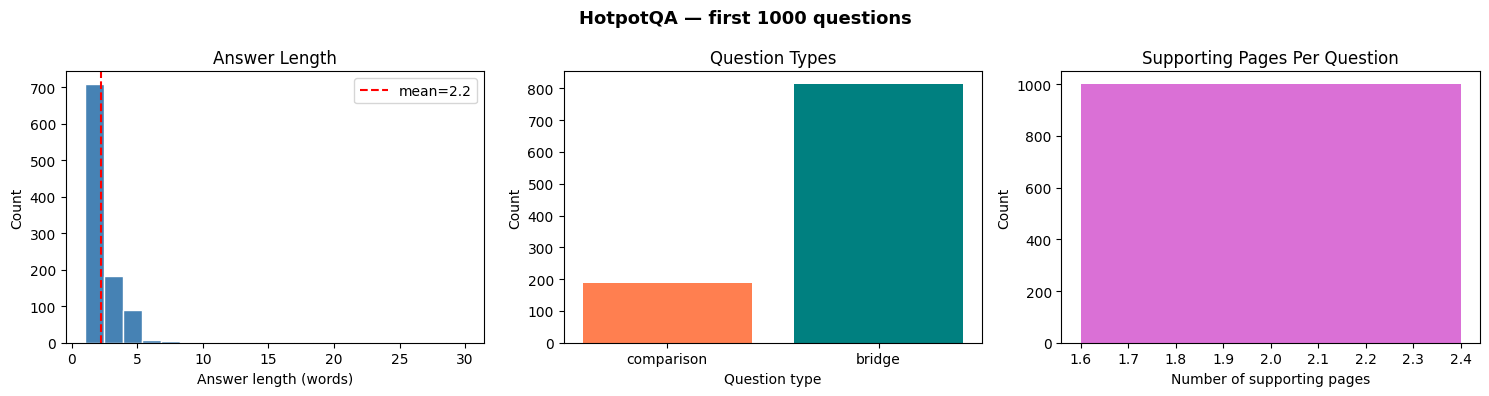

Saved: data/dataset_stats.png


In [7]:
# Sample  1000 questions for quick stats
N_SAMPLE = 1000
# N_SAMPLE = len(dataset)
samples = [dataset[i] for i in range(N_SAMPLE)]

answer_lengths  = [len(s['answer'].split()) for s in samples]
question_types  = Counter(s['type'] for s in samples)
supporting_counts = Counter(len(set(s['supporting_facts']['title'])) for s in samples)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'HotpotQA — first {N_SAMPLE} questions', fontsize=13, fontweight='bold')

# 1. Answer length
axes[0].hist(answer_lengths, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(sum(answer_lengths)/len(answer_lengths), color='red',
                linestyle='--', label=f'mean={sum(answer_lengths)/len(answer_lengths):.1f}')
axes[0].set_xlabel('Answer length (words)')
axes[0].set_ylabel('Count')
axes[0].set_title('Answer Length')
axes[0].legend()

# 2. Question types
axes[1].bar(question_types.keys(), question_types.values(),
            color=['coral', 'teal', 'gold'])
axes[1].set_xlabel('Question type')
axes[1].set_ylabel('Count')
axes[1].set_title('Question Types')

# 3. Supporting page count (always 2 for HotpotQA)
axes[2].bar(supporting_counts.keys(), supporting_counts.values(), color='orchid')
axes[2].set_xlabel('Number of supporting pages')
axes[2].set_ylabel('Count')
axes[2].set_title('Supporting Pages Per Question')

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'dataset_stats.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: data/dataset_stats.png')


In [8]:
question_types.get("bridge")

813

---
## Step 3 — Select 100 Questions for test

We use only **100 bridge-type questions** — enough to compare the three RAG systems without waiting hours.

> Bridge questions are harder: they explicitly require linking two Wikipedia pages.


In [9]:
N = 100
# N = question_types.get("bridge")
selected = []
for item in dataset:
    if item['type'] == 'bridge' and len(selected) < N:
        selected.append(item)
    if len(selected) >= N:
        break

print(f'Selected {len(selected)} bridge questions\n')
print(f'{"#":<4} {"Question":<60} {"Answer"}')
print('-' * 90)
for i, q in enumerate(selected):
    print(f'{i:<4} {q["question"][:58]:<60} {q["answer"]}')


Selected 100 bridge questions

#    Question                                                     Answer
------------------------------------------------------------------------------------------
0    The Oberoi family is part of a hotel company that has a he   Delhi
1    Musician and satirist Allie Goertz wrote a song about the    President Richard Nixon
2     What nationality was James Henry Miller's wife?             American
3    Cadmium Chloride is slightly soluble in this chemical, it    alcohol
4    Which genus of moth in the world's seventh-largest country   Crambidae
5    Who was once considered the best kick boxer in the world,    Badr Hari
6    The Dutch-Belgian television series that "House of Anubis"   2006
7    What is the length of the track where the 2013 Liqui Moly    6.213 km long
8    Fast Cars, Danger, Fire and Knives includes guest appearan   Jaime Meline
9    Gunmen from Laredo starred which narrator of "Frontier"?     Walter Darwin Coy
10   Where did the form of m

---
## Step 4 — Fetch Wikipedia Pages

For each question we need the two **supporting Wikipedia pages**. We fetch them using the Wikipedia REST API, getting:
- `text` — plain text (used by Simple RAG)
- `html` — structured HTML (used by HtmlRAG)
- `links` — list of linked article titles (used by HyperRAG)


In [10]:
# ── Request configuration ────────────────────────────────────────────────────
# Wikipedia requires a descriptive User-Agent with contact info.
# Requests without one get aggressively rate-limited.
USER_AGENT = 'HyperRAG/2.0 (academic research; contact: ravi.praj05@gmail.com)'

# Seconds to wait between each request (Wikipedia allows ~200 req/s for
# well-identified bots, but being polite avoids 429s on long runs).
REQUEST_DELAY = 0.15

# Proxy (optional) — set to e.g. 'http://IP:PORT' if behind a proxy, else None
PROXY_URL = None
PROXIES = {'http': PROXY_URL, 'https': PROXY_URL} if PROXY_URL else None

# Reuse a single TCP connection for all requests (much faster + fewer 429s)
_session = requests.Session()
_session.headers.update({'User-Agent': USER_AGENT})


def fetch_wikipedia_page(title: str) -> dict | None:
    """
    Fetch one Wikipedia page via the API.
    Returns dict with keys: title, text, html, links.
    Returns None if the page is not found or the response is invalid.
    """
    title = html_lib.unescape(title)   # decode HTML entities like &amp;
    url = 'https://en.wikipedia.org/w/api.php'
    params = {
        'action': 'parse',
        'page': title,
        'prop': 'text|links',
        'format': 'json',
        'redirects': True,
        'formatversion': 2,
    }

    time.sleep(REQUEST_DELAY)

    resp = None
    data = None
    max_retries = 8
    base_backoff_seconds = 2.0
    max_wait_seconds = 60.0

    for attempt in range(max_retries):
        try:
            resp = _session.get(url, params=params, timeout=30, proxies=PROXIES)

            if resp.status_code == 429:
                retry_after = resp.headers.get('Retry-After')
                default_wait = base_backoff_seconds * (2 ** attempt)
                try:
                    header_wait = float(retry_after) if retry_after else default_wait
                except (TypeError, ValueError):
                    header_wait = default_wait
                wait_seconds = min(max_wait_seconds, max(2.0, header_wait))
                if attempt == 0:
                    print(f'  RATE LIMITED for "{title}", backing off {wait_seconds:.0f}s ...')
                time.sleep(wait_seconds)
                continue

            resp.raise_for_status()
            content_type = resp.headers.get('content-type', '').lower()
            if 'json' not in content_type:
                preview = resp.text[:120].replace('\n', ' ')
                print(f'  ERROR fetching "{title}": non-JSON response ({content_type}). Preview: {preview}')
                return None

            data = resp.json()
            break

        except requests.RequestException as e:
            is_last_attempt = attempt == max_retries - 1
            if is_last_attempt:
                print(f'  ERROR fetching "{title}": HTTP/network issue: {e}')
                return None
            time.sleep(base_backoff_seconds * (2 ** attempt))
        except ValueError as e:
            preview = resp.text[:120].replace('\n', ' ') if resp is not None else ''
            print(f'  ERROR fetching "{title}": invalid JSON: {e}. Preview: {preview}')
            return None

    if data is None:
        print(f'  ERROR fetching "{title}": exceeded retry budget after rate limiting.')
        return None

    if 'error' in data or 'parse' not in data:
        print(f'  NOT FOUND: "{title}"')
        return None

    parse = data['parse']
    raw_html = parse['text']          # full HTML of the article

    # Plain text — strip wiki markup, tables, superscripts
    soup = BeautifulSoup(raw_html, 'html.parser')
    for tag in soup.find_all(['table', 'sup', 'style', 'script']):
        tag.decompose()
    text = ' '.join(soup.get_text(separator=' ', strip=True).split())

    # Links — namespace 0 means article links only (no Category:, File:, etc.)
    links = [
        lnk['title']
        for lnk in parse.get('links', [])
        if lnk.get('ns') == 0 and lnk.get('exists', False)
    ]

    # return {
    #     'title': title,
    #     'text': text[:8000],        # first 8 000 chars of plain text
    #     'html': raw_html[:15000],   # first 15 000 chars of HTML
    #     'links': links[:100],       # first 100 outgoing article links
    # }

    return {
        'title': title,
        'text': text[:],        # first 8 000 chars of plain text
        'html': raw_html[:],   # first 15 000 chars of HTML
        'links': links[:],       # first 100 outgoing article links
    }


print('fetch_wikipedia_page() defined.')


fetch_wikipedia_page() defined.


In [11]:
# ── Test the fetch function on one well-known page ────────────────────────────
test = fetch_wikipedia_page('Python (programming language)')
if test:
    print(f'title       : {test["title"]}')
    print(f'text length : {len(test["text"])} chars')
    print(f'html length : {len(test["html"])} chars')
    print(f'links (5)   : {test["links"][:5]}')
    print()
    print('Text preview (first 300 chars):')
    print(test['text'][:300])


title       : Python (programming language)
text length : 77037 chars
html length : 507407 chars
links (5)   : ['Python (programming language)', 'List of Python software', 'Comparison of integrated development environments', 'History of Python', 'Python syntax and semantics']

Text preview (first 300 chars):
General-purpose programming language Python is a high-level , general-purpose programming language that emphasizes code readability , simplicity, and ease-of-writing with the use of significant indentation , "plain English" naming, an extensive ("batteries-included") standard library , and garbage c


In [17]:
# Collect all unique supporting page titles across our 20 questions
needed_titles = set()
for q in selected:
    for title in q['supporting_facts']['title']:
        needed_titles.add(html_lib.unescape(title))

print(f'Unique Wikipedia pages to fetch: {len(needed_titles)}')
# for t in sorted(needed_titles):
#     print(f'  {t}')


Unique Wikipedia pages to fetch: 60881


In [18]:
# Thread-safe rate limiter — ensures minimum gap between requests
class RateLimiter:
    def __init__(self, min_interval: float):
        self._min_interval = min_interval
        self._lock = threading.Lock()
        self._last_call = 0.0

    def wait(self):
        with self._lock:
            now = time.monotonic()
            elapsed = now - self._last_call
            if elapsed < self._min_interval:
                time.sleep(self._min_interval - elapsed)
            self._last_call = time.monotonic()

# ~2 requests/sec keeps us well under Wikipedia's limit
rate_limiter = RateLimiter(min_interval=0.5)

def throttled_fetch(title: str) -> dict | None:
    rate_limiter.wait()
    return fetch_wikipedia_page(title)

# Fetch all pages in parallel (workers overlap network I/O; rate limiter controls pace)
corpus = {}
titles = sorted(needed_titles)
max_workers = min(4, len(titles)) or 1

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    future_to_title = {executor.submit(throttled_fetch, t): t for t in titles}

    for i, future in enumerate(as_completed(future_to_title), 1):
        title = future_to_title[future]
        print(f'[{i:>{len(str(len(titles)))}}/{len(titles)}] {title}')
        try:
            page = future.result()
            if page:
                corpus[page['title']] = page
        except Exception as exc:
            print(f'  -> failed: {title} ({exc})')

corpus_list = list(corpus.values())
print(f'\nFetched {len(corpus_list)} / {len(needed_titles)} pages successfully.')


[    1/60881] "Awaken, My Love!"
[    2/60881] "Dr. Death" Steve Williams
[    3/60881] "Heroes" (David Bowie album)
[    4/60881] "I Want" song
[    5/60881] "V" Is for Vagina
[    6/60881] "Heroes" (David Bowie song)
[    7/60881] "—And He Built a Crooked House—"
[    8/60881] "Weird Al" Yankovic
[    9/60881] '71 (film)
[   10/60881] '97 Bonnie & Clyde
[   11/60881] 'Round Springfield
[   12/60881] 'S Wonderful
[   13/60881] 'Til There Was You
[   14/60881] 'Tis the Fifteenth Season
[   15/60881] 'Tis the Voice of the Lobster
[   16/60881] 't Hooft symbol
[   17/60881] (Do You Love Me) Just Say Yes
[   18/60881] (Drawing) Rings Around the World
[   19/60881] (God Must Have Spent) A Little More Time on You
[   20/60881] (Everything I Do) I Do It for You
[   21/60881] (Pronounced 'Lĕh-'nérd 'Skin-'nérd)
[   22/60881] (The) New Release
[   23/60881] (Till) I Kissed You
[   24/60881] + (Ed Sheeran album)
[   25/60881] ...And Found
[   26/60881] +44 (band)
[   27/60881] ...und sowas muß 

---
## Step 5 — Explore the Corpus

Let's look at the corpus we just built before saving it.


In [ ]:
print(f'Corpus size : {len(corpus_list)} pages')
print(f'Keys per page: {list(corpus_list[0].keys())}')
print()
print(f'{"Page title":<45} {"Text chars":>10}  {"HTML chars":>10}  {"Links":>6}')
print('-' * 80)
for p in corpus_list:
    print(f'{p["title"][:43]:<45} {len(p["text"]):>10,}  {len(p["html"]):>10,}  {len(p["links"]):>6}')


Corpus size : 60307 pages
Keys per page: ['title', 'text', 'html', 'links']

Page title                                    Text chars  HTML chars   Links
--------------------------------------------------------------------------------
"Awaken, My Love!"                                20,217     176,276     165
"Dr. Death" Steve Williams                        43,367     336,629     820
"Heroes" (David Bowie album)                      49,393     322,329     395
"I Want" song                                      6,427      64,602     209
"V" Is for Vagina                                  4,904      60,451      66
"Heroes" (David Bowie song)                       62,423     453,536     797
"—And He Built a Crooked House—"                   5,101      21,841      25
"Weird Al" Yankovic                              134,258     736,230    1005
'71 (film)                                         9,744      55,781      81
'97 Bonnie & Clyde                                 4,007      60,643    

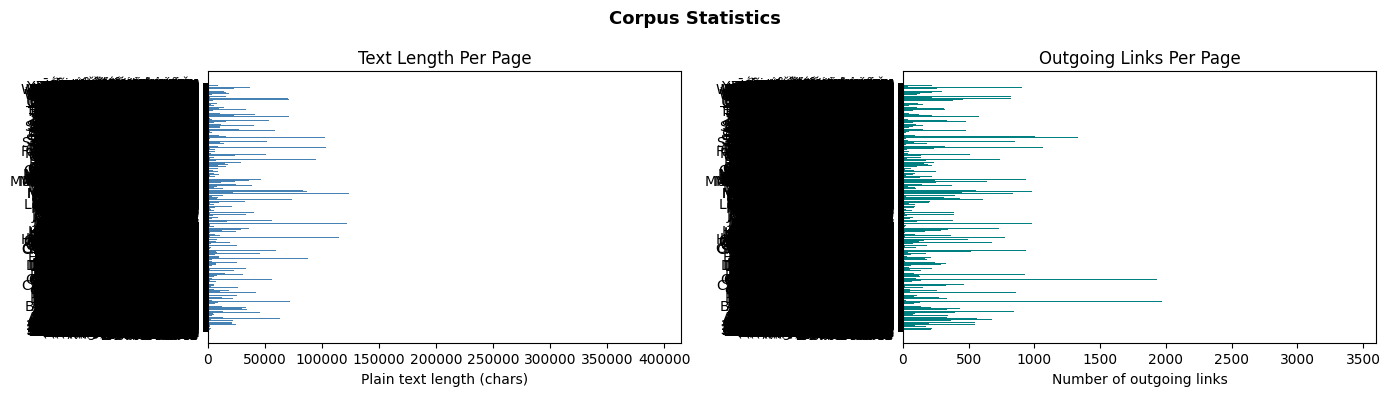

Saved: data/corpus_stats.png


In [20]:
text_lengths = [len(p['text']) for p in corpus_list]
link_counts  = [len(p['links']) for p in corpus_list]
titles_short = [p['title'][:20] for p in corpus_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Corpus Statistics', fontsize=13, fontweight='bold')

# Text lengths
axes[0].barh(titles_short, text_lengths, color='steelblue')
axes[0].set_xlabel('Plain text length (chars)')
axes[0].set_title('Text Length Per Page')

# Outgoing link count
axes[1].barh(titles_short, link_counts, color='teal')
axes[1].set_xlabel('Number of outgoing links')
axes[1].set_title('Outgoing Links Per Page')

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'corpus_stats.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: data/corpus_stats.png')


---
## Step 6 — Save Corpus & Questions

Save two JSON files that all other notebooks will load:
- `data/corpus.json` — Wikipedia pages (title, text, html, links)
- `data/questions.json` — 20 questions (question, answer, supporting_titles)


In [23]:
CHUNK_SIZE = 10_000  # max corpus pages per split

# Build title → corpus page lookup
title_to_page = {p['title']: p for p in corpus_list}

# Build simplified question list (preserves original order & global IDs)
all_questions = [
    {
        'id':                i,
        'question':          q['question'],
        'answer':            q['answer'],
        'type':              q['type'],
        'supporting_titles': list(set(q['supporting_facts']['title'])),
    }
    for i, q in enumerate(selected)
]

# Split into chunks: iterate questions, accumulate corpus pages per chunk
chunks = []          # list of (chunk_corpus_dict, chunk_questions_list)
cur_corpus = {}      # title → page for current chunk
cur_questions = []

for q in all_questions:
    titles_needed = q['supporting_titles']
    new_titles = [t for t in titles_needed if t not in cur_corpus]
    would_exceed = len(cur_corpus) + len(new_titles) > CHUNK_SIZE

    if would_exceed and cur_questions:
        chunks.append((cur_corpus, cur_questions))
        cur_corpus = {}
        cur_questions = []

    for t in titles_needed:
        if t not in cur_corpus and t in title_to_page:
            cur_corpus[t] = title_to_page[t]
    cur_questions.append(q)

if cur_questions:
    chunks.append((cur_corpus, cur_questions))

# Save each chunk: corpus_001.json / questions_001.json, etc.
print(f'Total: {len(all_questions)} questions, {len(corpus_list)} corpus pages \u2192 {len(chunks)} chunks\n')

for idx, (chunk_corp, chunk_qs) in enumerate(chunks, start=1):
    tag = f'{idx:03d}'
    corpus_path   = DATA_DIR / f'corpus_{tag}.json'
    questions_path = DATA_DIR / f'questions_{tag}.json'

    with open(corpus_path, 'w', encoding='utf-8') as f:
        json.dump(list(chunk_corp.values()), f, indent=2, ensure_ascii=False)

    with open(questions_path, 'w', encoding='utf-8') as f:
        json.dump(chunk_qs, f, indent=2, ensure_ascii=False)

    print(f'Chunk {tag}: {len(chunk_corp):>6} pages \u2192 {corpus_path.name}')
    print(f'           {len(chunk_qs):>6} questions \u2192 {questions_path.name}')


Total: 40375 questions, 60307 corpus pages → 8 chunks

Chunk 001:   9999 pages → corpus_001.json
             5329 questions → questions_001.json
Chunk 002:   9999 pages → corpus_002.json
             5337 questions → questions_002.json
Chunk 003:  10000 pages → corpus_003.json
             5339 questions → questions_003.json
Chunk 004:  10000 pages → corpus_004.json
             5305 questions → questions_004.json
Chunk 005:   9999 pages → corpus_005.json
             5349 questions → questions_005.json
Chunk 006:  10000 pages → corpus_006.json
             5347 questions → questions_006.json
Chunk 007:  10000 pages → corpus_007.json
             5345 questions → questions_007.json
Chunk 008:   5803 pages → corpus_008.json
             3024 questions → questions_008.json


In [ ]:
# ── Verify the first chunk loads correctly ─────────────────────────────────
import glob as _glob

corpus_files = sorted(DATA_DIR.glob('corpus_*.json'))
question_files = sorted(DATA_DIR.glob('questions_*.json'))

print(f'Found {len(corpus_files)} corpus chunks and {len(question_files)} question chunks\n')

total_pages = 0
total_questions = 0
for cf, qf in zip(corpus_files, question_files):
    with open(cf) as f: c = json.load(f)
    with open(qf) as f: q = json.load(f)
    print(f'{cf.name}: {len(c):>6} pages   |   {qf.name}: {len(q):>6} questions')
    total_pages += len(c)
    total_questions += len(q)
    del c, q  # free memory immediately

print(f'\nTotal: {total_pages} pages, {total_questions} questions across {len(corpus_files)} chunks')
print()

# Quick-check first chunk
with open(question_files[0]) as f: sample_q = json.load(f)
print('Sample question 0:')
print(f'  Q  : {sample_q[0]["question"]}')
print(f'  A  : {sample_q[0]["answer"]}')
print(f'  Pages needed: {sample_q[0]["supporting_titles"]}')
print()
print('All done! Use corpus_001.json / questions_001.json (etc.) in downstream notebooks.')
